In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [1]:
from sklearn.datasets import load_diabetes
dataset=load_diabetes()
dataset


{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [10]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X=pd.DataFrame(dataset['data'],columns=['age',
  'sex',
  'bmi',
  'bp',
  's1',
  's2',
  's3',
  's4',
  's5',
  's6'])
y=dataset['target']

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)
X_train

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
415,-0.005515,-0.044642,0.008883,-0.050427,0.025950,0.047224,-0.043401,0.071210,0.014821,0.003064
338,-0.063635,-0.044642,-0.033151,-0.033213,0.001183,0.024051,-0.024993,-0.002592,-0.022517,-0.059067
270,0.005383,0.050680,0.030440,0.083844,-0.037344,-0.047347,0.015505,-0.039493,0.008641,0.015491
126,-0.089063,-0.044642,-0.061174,-0.026328,-0.055231,-0.054549,0.041277,-0.076395,-0.093937,-0.054925
281,-0.092695,0.050680,-0.090275,-0.057313,-0.024960,-0.030437,-0.006584,-0.002592,0.024055,0.003064
...,...,...,...,...,...,...,...,...,...,...
369,-0.009147,-0.044642,0.037984,-0.040099,-0.024960,-0.003819,-0.043401,0.015858,-0.005142,0.027917
320,-0.023677,-0.044642,0.030440,-0.005670,0.082364,0.092004,-0.017629,0.071210,0.033043,0.003064
15,-0.052738,0.050680,-0.018062,0.080401,0.089244,0.107662,-0.039719,0.108111,0.036060,-0.042499
125,-0.005515,0.050680,-0.008362,-0.002228,-0.033216,-0.063630,-0.036038,-0.002592,0.080590,0.007207


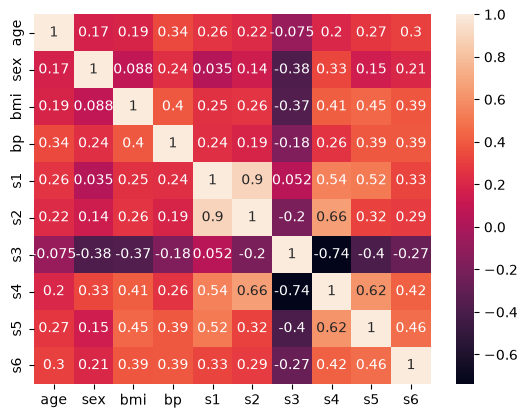

In [9]:
plt.Figure(figsize=(15,10))
sns.heatmap(X.corr(),annot=True)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error
reg=DecisionTreeRegressor()
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

57.93693693693694
0.02275773387537061


In [13]:
params={
    'criterion':['squared_error', 'absolute_error', 'poisson'],
    'splitter':['best', 'random'],
    'max_depth':[1,2,3,4,5,6,7,8,10,15,20,25,50],
    'max_features':['sqrt', 'log2']
}
params

{'criterion': ['squared_error', 'absolute_error', 'poisson'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 50],
 'max_features': ['sqrt', 'log2']}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(DecisionTreeRegressor(),param_grid=params,cv=5,scoring='neg_mean_absolute_error',verbose=3,refit=True)
grid.fit(X_train,y_train)
g_pred=grid.predict(X_test)
print(mean_absolute_error(y_test,g_pred))
print(r2_score(y_test,g_pred))

Fitting 5 folds for each of 156 candidates, totalling 780 fits
[CV 1/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-59.739 total time=   0.2s
[CV 2/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-53.253 total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-58.944 total time=   0.0s
[CV 4/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-57.577 total time=   0.0s
[CV 5/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-57.957 total time=   0.0s
[CV 1/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-70.826 total time=   0.0s
[CV 2/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-58.721 total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-57.40

In [15]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'random'}

In [16]:
reg1=DecisionTreeRegressor(criterion= 'squared_error',
 max_depth= 4,
 max_features= 'sqrt',
 splitter= 'random')
reg1.fit(X_train,y_train)
y_pred=reg1.predict(X_test)
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

55.592732070305594
0.3224875356228706


[Text(0.5, 0.9, 'x[8] <= -0.03\nsquared_error = 5808.76\nsamples = 331\nvalue = 153.1'),
 Text(0.25, 0.7, 'x[2] <= 0.036\nsquared_error = 2020.675\nsamples = 93\nvalue = 100.57'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[1] <= -0.023\nsquared_error = 1995.831\nsamples = 85\nvalue = 97.8'),
 Text(0.0625, 0.3, 'x[2] <= 0.011\nsquared_error = 2269.158\nsamples = 56\nvalue = 106.143'),
 Text(0.03125, 0.1, 'squared_error = 2045.147\nsamples = 51\nvalue = 102.431'),
 Text(0.09375, 0.1, 'squared_error = 2980.4\nsamples = 5\nvalue = 144.0'),
 Text(0.1875, 0.3, 'x[4] <= 0.018\nsquared_error = 1074.076\nsamples = 29\nvalue = 81.69'),
 Text(0.15625, 0.1, 'squared_error = 1093.706\nsamples = 27\nvalue = 79.815'),
 Text(0.21875, 0.1, 'squared_error = 121.0\nsamples = 2\nvalue = 107.0'),
 Text(0.375, 0.5, 'x[5] <= -0.008\nsquared_error = 1337.0\nsamples = 8\nvalue = 130.0'),
 Text(0.3125, 0.3, 'x[1] <= -0.016\nsquared_error = 1063.5\nsamples = 4\nvalue = 140.0'),
 Text(0.28125, 0.1, 'square

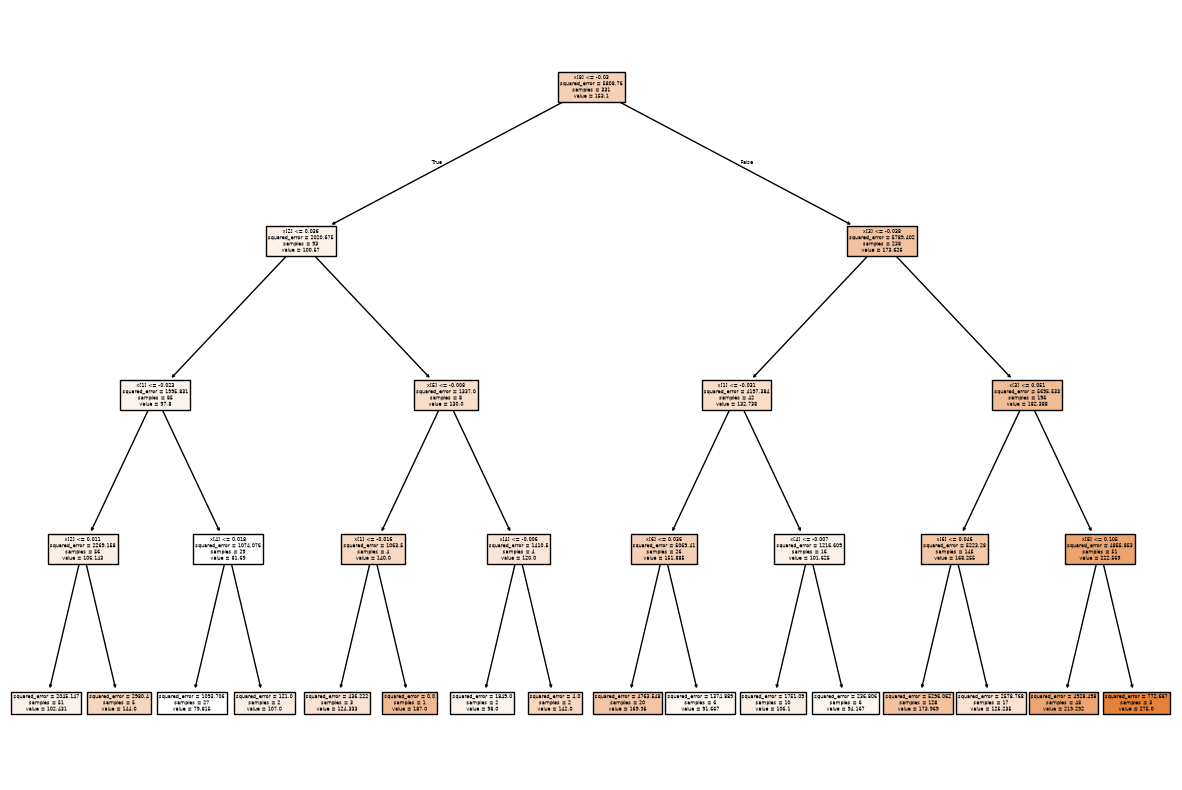

In [17]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(reg1,filled=True)

# we Brougth the r2_score from 0.022 to 0.3224 by the help of hyperparmeter tuning